### 第1回講義
# <span style="color:rgb(65, 105, 192)">物質収支と反応器設計方程式</span>
### CSTR（連続槽反応器）とPFR（管型反応器）
---

## 学習目標

学部「反応工学」の復習
- 一般的な物質収支式を理解する
- CSTRの設計方程式を導出できる
- PFRの設計方程式を導出できる
- 転化率を用いた設計方程式に変換できる
- CSTRとPFRの違いを説明できる

---

<figure style="text-align:center;">
<img
src="https://raw.githubusercontent.com/myokota812/lecture/master/AdvChE/figure/matebala.svg"
width="600">
</figure>

## 一般物質収支

$$蓄積 = 流入 - 流出 + 反応(+生成/-消費)$$

化学種Aについて

$$\frac{dN_A}{dt}=F_{A0}-F_A+r_AV$$

## 定常状態

$$\frac{dN_A}{dt}=0$$

したがって

$$F_{A0}-F_A+r_AV=0$$

## CSTRの設計方程式

<figure style="text-align:center;">
  <img
    src="https://raw.githubusercontent.com/myokota812/lecture/master/AdvChE/figure/cstr2.svg"
    width="300">
</figure>

定常状態物質収支より

$$F_{A0}-F_A+r_AV=0$$

$$V=\frac{F_{A0}-F_A}{-r_A}$$

もしくは転化率$X$を用いる場合

$$X=\frac{F_{A0}-F_A}{F_{A0}}$$

より

$$V=\frac{F_{A0}X}{-r_A} \tag{1}$$



## PFRの設計方程式
<figure style="text-align:center;">
  <img
    src="https://raw.githubusercontent.com/myokota812/lecture/master/AdvChE/figure/pfr2.svg"
    width="600">
</figure>

微小体積 $dV$ に対する物質収支

$$F_A-(F_A+dF_A)+r_A dV=0$$

$$\frac{dF_A}{dV}=r_A$$

したがって入口 $(V=0,\;F_A=F_{A0})$ から出口 $(V=V,\;F_A=F_A)$ まで積分して
$$
V=\int_{F_{A0}}^{F_A}\frac{dF_A}{r_A}.
$$


通常は反応物 A について $r_A<0$ なので、

$$
V=\int_{F_A}^{F_{A0}}\frac{dF_A}{-r_A}
$$

と書くことが多いです。

◇◇◇
転化率を導入すると

$$F_A=F_{A0}(1-X)$$

$$dF_A=-F_{A0}dX$$

したがって

$$dV=\frac{F_{A0}}{-r_A}dX$$

積分して

$$V=F_{A0}\int_0^X \frac{dX}{-r_A} \tag{2}$$

---

## CSTRとPFRの比較

- <h4> CSTR (Eq.1):</h4>

$$V=\frac{F_{A0}X}{-r_A}$$

- <h4>PFR(Eq. 2):</h4>

$$V=F_{A0}\int_0^X \frac{dX}{-r_A}$$

一般に正の反応次数ではPFRの方が小体積で高転化率を達成できる。

## 一次反応への適用

$$A\rightarrow B$$

$$-r_A=kC_A$$

$$C_A=C_{A0}(1-X)$$

- #### CSTR

$$V=\frac{F_{A0}X}{kC_{A0}(1-X)}$$

- #### PFR

$$
V=\frac{F_{A0}}{kC_{A0}}\ln\left(\frac{1}{1-X}\right)
$$

## 空間時間

空間時間$\tau$は
$$
\tau = ~\frac{V}{v}
$$
で定義される、時間の次元を持つ量である。

ここで、$v\ [\mathrm{m}^3 \cdot \mathrm{s}^{-1}]$は溶液の体積流量。 
$$
F_{A0} = C_{A0} v
$$
だから

空間時間を使った設計方程式は

- <h4>CSTR:</h4>

$$\tau=\frac{X}{k(1-X)}$$

- <h4>PFR:</h4>

$$\tau=\frac{1}{k}\ln\left(\frac{1}{1-X}\right)$$

## 演習問題

1. 一次反応で X=0.8 を達成するためのCSTRとPFRの空間時間を求めよ。
2. 下記のpythonコードを実行して、出力されるグラフを見てください。そのうえで、この計算の目的とそこから得られる知見を記述しなさい。


In [ ]:
#@title演習２のpythonコード
import numpy as np
import matplotlib.pyplot as plt

k = 1.0
CA0 = 1.0

X = np.linspace(0.001, 0.95, 500)

def tau_pfr(X, n, k=1.0, CA0=1.0):

    if np.isclose(n, 0):
        return X / (k / CA0)

    elif np.isclose(n, 1):
        return np.log(1/(1-X)) / k

    else:
        return ((1-X)**(1-n)-1)/(
            (n-1)*k*CA0**(n-1)
        )

def tau_cstr(X, n, k=1.0, CA0=1.0):

    if np.isclose(n, 0):
        return X/(k/CA0)

    return X/(
        k*CA0**(n-1)*(1-X)**n
    )

orders = [0,1,2,3]

fig, axes = plt.subplots(
    2, 2,
    figsize=(10,8),
    sharex=True
)

axes = axes.flatten()

for ax, n in zip(axes, orders):

    ax.plot(
        X,
        tau_pfr(X,n,k,CA0),
        lw=3,
        label="PFR"
    )

    ax.plot(
        X,
        tau_cstr(X,n,k,CA0),
        "--",
        lw=3,
        label="CSTR"
    )

    ax.set_title(f"n={n}")
    ax.grid(True)
    ax.legend()

    ax.set_xlabel("Conversion X")
    ax.set_ylabel(r"$\tau$")

plt.tight_layout()
plt.show()

---

## 演1解答例

一次反応

$A \rightarrow B \,\left(-r_A=kC_A \right) $  

$$
C_A=C_{A0}(1-X)
$$


#### $\boxed{\text{PFR}}$
- 設計方程式

$$
V=F_{A0}\int_0^X\frac{dX}{-r_A}
$$
に
$$
-r_A=kC_{A0}(1-X)
$$
を代入すると
$$
V = F_{A0} \int_0^X \frac{dX} {kC_{A0}(1-X)}
$$
ここで
$$
F_{A0}=v C_{A0}
$$
より
$$
V = \frac{v}{k} \int_0^X \frac{dX}{1-X}
$$

- 空間時間

$$
\tau=\frac{V}{v}
$$
だから

$$
\tau_{\rm PFR} = \frac1k \int_0^X \frac{dX}{1-X}
$$
積分すると

$$
\tau_{\rm PFR} = -\frac1k\ln(1-X)
$$

したがって$X=0.8$では

$$
\tau_{\rm PFR} = -\frac1k\ln(0.2) = \frac{1.609}{k}
$$

#### $\boxed{\text{CSTR}}$

定常状態物質収支

$$
F_{A0}-F_A+Vr_A=0
$$
より
$$
V= \frac{F_{A0}X}{-r_A}
$$
出口条件を代入すると

$$
-r_A=kC_A = kC_{A0}(1-X)
$$

したがって
$$
\begin{aligned}
V &= \frac{F_{A0}X} {kC_{A0}(1-X)}\\ 
F_{A0}&=vC_{A0}
\end{aligned}
$$
より

$$
\tau_{\rm CSTR} = \frac{X}{k(1-X)} 
$$
$X=0.8$を代入すると

$$
\tau_{\rm CSTR} = \frac{0.8}{0.2k} = \frac{4}{k}
$$
となり
$$
\tau_{\rm CSTR}>\tau_{\rm PFR}
$$
です。

つまり、$v$が同じという条件で比較すると、一次反応で転化率 80 % を達成するには、CSTR は PFR の約 2.5 倍の空間時間（体積）が必要になります。




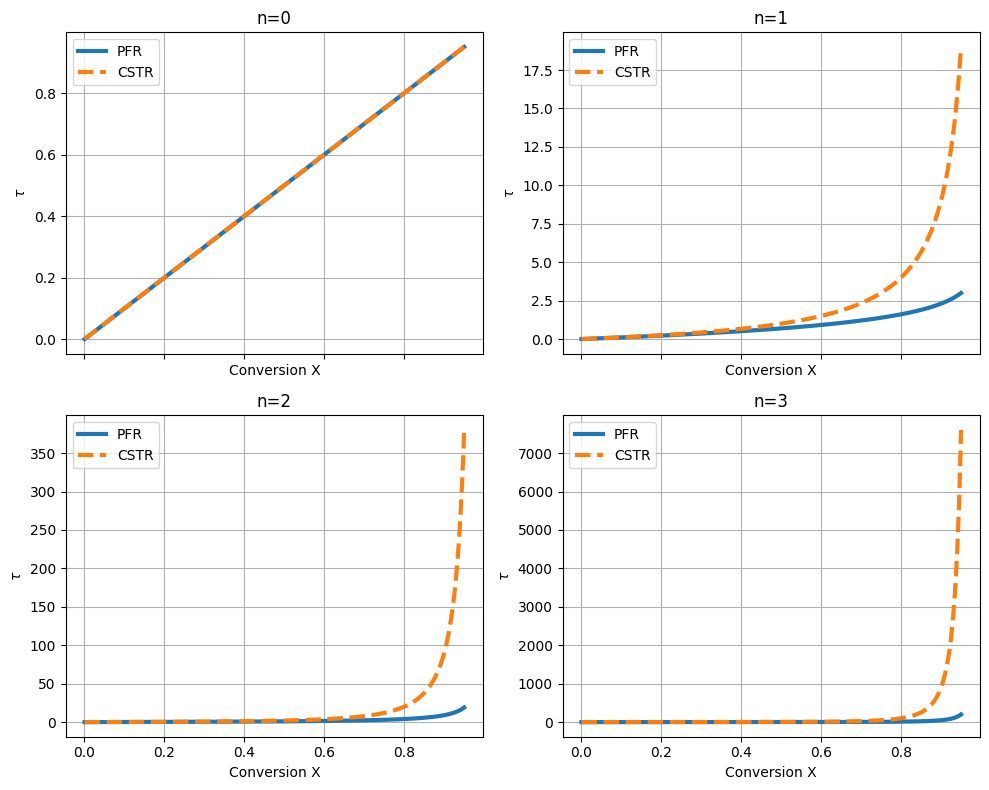

In [ ]:
#@title演習２のpythonコード
import numpy as np
import matplotlib.pyplot as plt

k = 1.0
CA0 = 1.0

X = np.linspace(0.001, 0.95, 500)

def tau_pfr(X, n, k=1.0, CA0=1.0):

    if np.isclose(n, 0):
        return X / (k / CA0)

    elif np.isclose(n, 1):
        return np.log(1/(1-X)) / k

    else:
        return ((1-X)**(1-n)-1)/(
            (n-1)*k*CA0**(n-1)
        )

def tau_cstr(X, n, k=1.0, CA0=1.0):

    if np.isclose(n, 0):
        return X/(k/CA0)

    return X/(
        k*CA0**(n-1)*(1-X)**n
    )

orders = [0,1,2,3]

fig, axes = plt.subplots(
    2, 2,
    figsize=(10,8),
    sharex=True
)

axes = axes.flatten()

for ax, n in zip(axes, orders):

    ax.plot(
        X,
        tau_pfr(X,n,k,CA0),
        lw=3,
        label="PFR"
    )

    ax.plot(
        X,
        tau_cstr(X,n,k,CA0),
        "--",
        lw=3,
        label="CSTR"
    )

    ax.set_title(f"n={n}")
    ax.grid(True)
    ax.legend()

    ax.set_xlabel("Conversion X")
    ax.set_ylabel(r"$\tau$")

plt.tight_layout()
plt.show()